# SVM Image Classification — HOG + LBP Features (PCA-Reduced)

---

## Overview

This notebook trains and evaluates a **Support Vector Machine (SVM)** classifier on pre-extracted, PCA-reduced image features:

- **HOG (Histogram of Oriented Gradients):** Captures edge/shape structure via gradient orientations in local image patches.
- **LBP (Local Binary Patterns):** Captures texture information by thresholding pixel neighbourhoods.
- **PCA:** Already applied upstream — features are already dimensionality-reduced. No further scaling is needed.

The pipeline covers:
1. Data loading and exploration
2. Train/test split (stratified 80/20)
3. SVM training (RBF kernel, fixed hyperparameters — no grid search)
4. Cross-validation on training set
5. Evaluation: accuracy, F1, classification report, confusion matrix, per-class metrics
6. Model persistence (`joblib` save)

**No grid search. No scaling.** The model uses `C=1.0`, `gamma='scale'` throughout.

---
## 1. Imports & Global Settings

In [1]:
# ============================================================
# Cell 1: Import all required libraries and configure globals.
# Sets numpy random seed for full reproducibility.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time
import joblib

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

# ── Global settings ──────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore')

# ── Plot style ───────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 100,
    'font.size'       : 11,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'legend.fontsize' : 10,
    'figure.facecolor': 'white',
})
sns.set_style('whitegrid')

# ── Output directories ───────────────────────────────────────
os.makedirs('figures', exist_ok=True)
os.makedirs('models',  exist_ok=True)

print('All imports successful.')
print(f'   NumPy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')
print(f'   Random seed set to: {RANDOM_SEED}')

All imports successful.
   NumPy  : 2.0.2
   Pandas : 2.2.2
   Random seed set to: 42


---
## 2. Data Loading & Exploration

In [3]:
# ============================================================
# Cell 2: Load pre-extracted, PCA-reduced feature arrays.
# Prints shapes, number of classes, and class distribution.
# ============================================================

X = np.load('XPCA_features_80.npy')
y = np.load('y_labels.npy')

print('=' * 50)
print('DATASET OVERVIEW')
print('=' * 50)
print(f'Feature matrix shape  : {X.shape}  (samples , features)')
print(f'Label vector shape    : {y.shape}')
print(f'Total samples         : {X.shape[0]}')
print(f'Total features        : {X.shape[1]}  (PCA-reduced)')

# ── Class information ────────────────────────────────────────
unique_classes, class_counts = np.unique(y, return_counts=True)
n_classes = len(unique_classes)
print(f'\nNumber of classes     : {n_classes}')
print(f'Class labels          : {unique_classes}')
print('\nClass distribution:')
for cls, cnt in zip(unique_classes, class_counts):
    pct = cnt / len(y) * 100
    print(f'   Class {cls:>3}  ->  {cnt:>5} samples  ({pct:.1f}%)')

# ── Feature statistics ────────────────────────────────────────
print(f'\nFeature value range   : [{X.min():.4f}, {X.max():.4f}]')
print(f'Feature mean          : {X.mean():.4f}')
print(f'Feature std           : {X.std():.4f}')

# ── Check for NaN / Inf ──────────────────────────────────────
nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()
print(f'\nNaN values            : {nan_count}')
print(f'Inf values            : {inf_count}')
if nan_count == 0 and inf_count == 0:
    print('Data is clean -- no NaN or Inf values.')

DATASET OVERVIEW
Feature matrix shape  : (4844, 700)  (samples , features)
Label vector shape    : (4844,)
Total samples         : 4844
Total features        : 700  (PCA-reduced)

Number of classes     : 3
Class labels          : [0 1 2]

Class distribution:
   Class   0  ->   1603 samples  (33.1%)
   Class   1  ->   1603 samples  (33.1%)
   Class   2  ->   1638 samples  (33.8%)

Feature value range   : [-49.4303, 53.7179]
Feature mean          : -0.0000
Feature std           : 3.0449

NaN values            : 0
Inf values            : 0
Data is clean -- no NaN or Inf values.


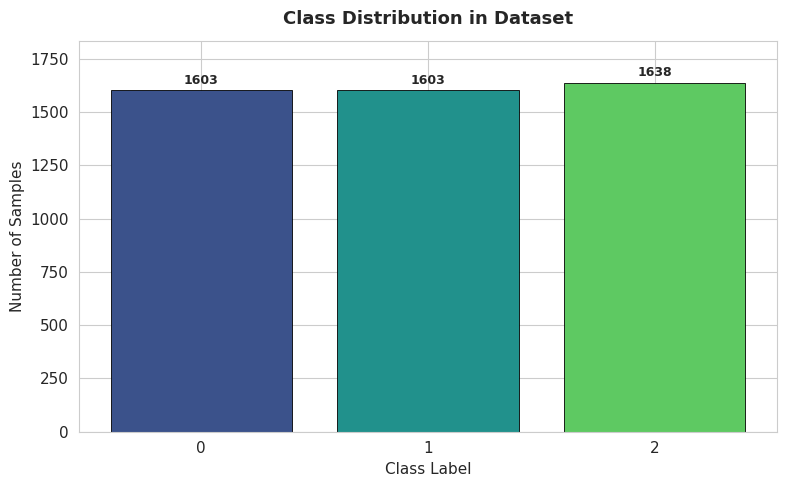

Figure saved : figures/class_distribution.png


In [4]:
# ============================================================
# Cell 3: Visualise class distribution as a bar chart.
# ============================================================

fig, ax = plt.subplots(figsize=(max(8, n_classes * 0.7), 5))
colors = sns.color_palette('viridis', n_classes)
bars = ax.bar(unique_classes.astype(str), class_counts,
              color=colors, edgecolor='black', linewidth=0.6)

for bar, cnt in zip(bars, class_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(class_counts) * 0.01,
        str(cnt), ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_title('Class Distribution in Dataset', fontweight='bold', pad=12)
ax.set_xlabel('Class Label')
ax.set_ylabel('Number of Samples')
ax.set_ylim(0, max(class_counts) * 1.12)
plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved : figures/class_distribution.png')

---
## 3. Train / Test Split

Stratified 80/20 split. **No scaling applied** — PCA was already performed upstream.

In [5]:
# ============================================================
# Cell 4: Split data 80/20 train/test with stratification.
# No scaling -- features are already PCA-reduced.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

print('=' * 50)
print('TRAIN / TEST SPLIT')
print('=' * 50)
print(f'Training samples  : {X_train.shape[0]}  ({X_train.shape[0]/X.shape[0]*100:.1f}%)')
print(f'Test samples      : {X_test.shape[0]}   ({X_test.shape[0]/X.shape[0]*100:.1f}%)')
print(f'Feature dimension : {X_train.shape[1]}  (PCA-reduced)')
print('\nTrain class counts:')
for cls, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f'   Class {cls}: {cnt}')
print('\nTest class counts:')
for cls, cnt in zip(*np.unique(y_test, return_counts=True)):
    print(f'   Class {cls}: {cnt}')
print('\nNote: features are already PCA-reduced -- no further scaling applied.')

TRAIN / TEST SPLIT
Training samples  : 3875  (80.0%)
Test samples      : 969   (20.0%)
Feature dimension : 700  (PCA-reduced)

Train class counts:
   Class 0: 1282
   Class 1: 1283
   Class 2: 1310

Test class counts:
   Class 0: 321
   Class 1: 320
   Class 2: 328

Note: features are already PCA-reduced -- no further scaling applied.


---
## 4. SVM Training

Fixed hyperparameters — no grid search:

| Parameter | Value |
|-----------|-------|
| Kernel    | RBF   |
| C         | 1.0   |
| gamma     | scale |
| decision_function_shape | ovr |

In [6]:
# ============================================================
# Cell 5: Train SVM on all PCA-reduced features.
# No grid search -- fixed hyperparameters.
# ============================================================

print('Training SVM ...')
t0 = time.time()

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    decision_function_shape='ovr',
    random_state=RANDOM_SEED,
    probability=True
)
svm_model.fit(X_train, y_train)

elapsed = time.time() - t0
print(f'Training complete in {elapsed:.1f}s')
print('\nSVM parameters:')
for k, v in svm_model.get_params().items():
    print(f'   {k:<30}: {v}')

Training SVM ...
Training complete in 25.9s

SVM parameters:
   C                             : 1.0
   break_ties                    : False
   cache_size                    : 200
   class_weight                  : None
   coef0                         : 0.0
   decision_function_shape       : ovr
   degree                        : 3
   gamma                         : scale
   kernel                        : rbf
   max_iter                      : -1
   probability                   : True
   random_state                  : 42
   shrinking                     : True
   tol                           : 0.001
   verbose                       : False


---
## 5. Cross-Validation on Training Set

Running 5-fold cross-validation on training set ...

CV Fold Accuracies : [0.82322581 0.84258065 0.83354839 0.82451613 0.83354839]
CV Mean Accuracy   : 0.8315
CV Std             : 0.0070
Completed in       : 25.2s


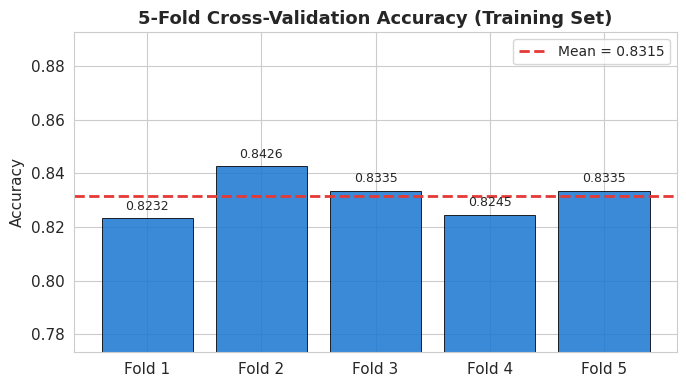

Figure saved : figures/cv_fold_accuracies.png


In [7]:
# ============================================================
# Cell 6: 5-fold cross-validation on the training set.
# Test set is NOT touched here.
# ============================================================

print('Running 5-fold cross-validation on training set ...')
t0 = time.time()

cv_svm = SVC(
    kernel='rbf', C=1.0, gamma='scale',
    decision_function_shape='ovr',
    random_state=RANDOM_SEED
)
cv_scores = cross_val_score(cv_svm, X_train, y_train, cv=5,
                             scoring='accuracy', n_jobs=-1)
elapsed = time.time() - t0

print(f'\nCV Fold Accuracies : {cv_scores}')
print(f'CV Mean Accuracy   : {cv_scores.mean():.4f}')
print(f'CV Std             : {cv_scores.std():.4f}')
print(f'Completed in       : {elapsed:.1f}s')

# ── Plot CV fold accuracies ──────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
folds = [f'Fold {i+1}' for i in range(len(cv_scores))]
bars  = ax.bar(folds, cv_scores, color='#1976D2', edgecolor='black',
               linewidth=0.7, alpha=0.85)
ax.axhline(cv_scores.mean(), color='#E53935', linestyle='--',
           linewidth=2, label=f'Mean = {cv_scores.mean():.4f}')
for bar, sc in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{sc:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_title('5-Fold Cross-Validation Accuracy (Training Set)', fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(max(0, cv_scores.min() - 0.05), min(1.0, cv_scores.max() + 0.05))
ax.legend()
plt.tight_layout()
plt.savefig('figures/cv_fold_accuracies.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved : figures/cv_fold_accuracies.png')

---
## 6. Test Set Evaluation

In [8]:
# ============================================================
# Cell 7: Evaluate trained SVM on the held-out test set.
# Reports accuracy, F1, and full classification report.
# ============================================================

y_pred = svm_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_f1       = f1_score(y_test, y_pred, average='weighted')

print('=' * 50)
print('SVM TEST SET RESULTS')
print('=' * 50)
print(f'Features used         : {X_train.shape[1]}  (PCA-reduced)')
print(f'Test Accuracy         : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)')
print(f'Weighted F1-Score     : {test_f1:.4f}')
print(f'CV Mean Accuracy      : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

SVM TEST SET RESULTS
Features used         : 700  (PCA-reduced)
Test Accuracy         : 0.8308  (83.08%)
Weighted F1-Score     : 0.8293
CV Mean Accuracy      : 0.8315 +/- 0.0070

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       321
           1       0.80      0.72      0.76       320
           2       0.89      0.92      0.90       328

    accuracy                           0.83       969
   macro avg       0.83      0.83      0.83       969
weighted avg       0.83      0.83      0.83       969



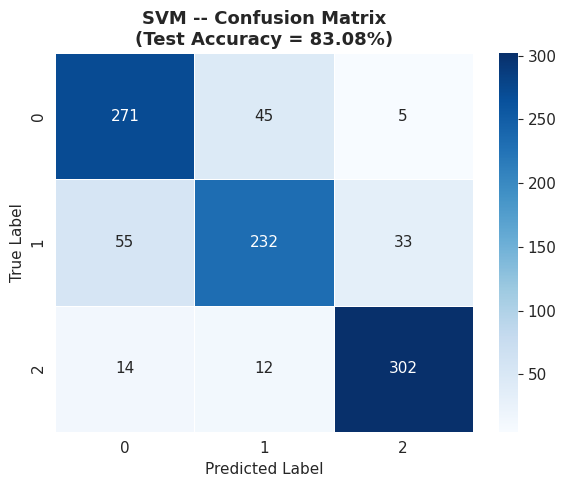

Figure saved -> figures/svm_confusion_matrix.png


In [9]:
# ============================================================
# Cell 8: Plot confusion matrix as a heatmap.
# ============================================================

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(max(6, n_classes), max(5, n_classes - 1)))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=unique_classes,
    yticklabels=unique_classes,
    linewidths=0.5, ax=ax
)
ax.set_title(
    f'SVM -- Confusion Matrix\n(Test Accuracy = {test_accuracy*100:.2f}%)',
    fontweight='bold'
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('figures/svm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved -> figures/svm_confusion_matrix.png')

---
## 7. Per-Class Metrics

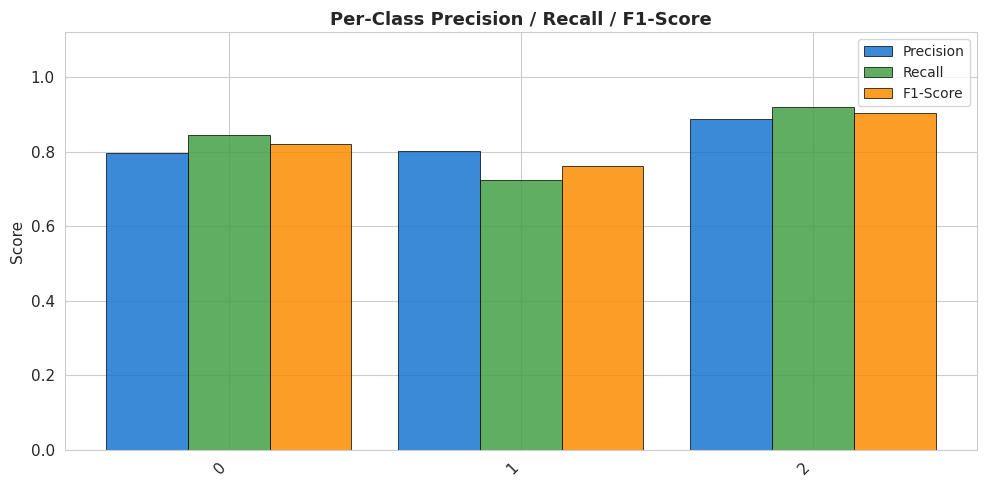

Figure saved -> figures/per_class_metrics.png


In [10]:
# ============================================================
# Cell 9: Per-class precision, recall, F1 bar charts.
# ============================================================

precision_per_class = precision_score(y_test, y_pred, average=None, labels=unique_classes)
recall_per_class    = recall_score(y_test,    y_pred, average=None, labels=unique_classes)
f1_per_class        = f1_score(y_test,        y_pred, average=None, labels=unique_classes)

x     = np.arange(n_classes)
width = 0.28

fig, ax = plt.subplots(figsize=(max(10, n_classes * 0.9), 5))
ax.bar(x - width, precision_per_class, width, label='Precision', color='#1976D2',
       edgecolor='black', linewidth=0.6, alpha=0.85)
ax.bar(x,          recall_per_class,   width, label='Recall',    color='#43A047',
       edgecolor='black', linewidth=0.6, alpha=0.85)
ax.bar(x + width,  f1_per_class,       width, label='F1-Score',  color='#FB8C00',
       edgecolor='black', linewidth=0.6, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(unique_classes.astype(str), rotation=45, ha='right')
ax.set_title('Per-Class Precision / Recall / F1-Score', fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.legend()
plt.tight_layout()
plt.savefig('figures/per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved -> figures/per_class_metrics.png')

---
## 8. Results Summary

In [11]:
# ============================================================
# Cell 10: Consolidated results summary table.
# ============================================================

summary = pd.DataFrame({
    'Metric' : ['Test Accuracy', 'Weighted F1-Score',
                'CV Mean Accuracy', 'CV Std',
                'Total Features (PCA)', 'Kernel', 'C', 'Gamma'],
    'Value'  : [
        f'{test_accuracy:.4f}',
        f'{test_f1:.4f}',
        f'{cv_scores.mean():.4f}',
        f'{cv_scores.std():.4f}',
        str(X_train.shape[1]),
        'RBF',
        '1.0',
        'scale',
    ]
})

print('=' * 45)
print('FINAL RESULTS SUMMARY')
print('=' * 45)
print(summary.to_string(index=False))
print('=' * 45)

summary.to_csv('svm_results_summary.csv', index=False)
print('\nSaved: svm_results_summary.csv')

FINAL RESULTS SUMMARY
              Metric  Value
       Test Accuracy 0.8308
   Weighted F1-Score 0.8293
    CV Mean Accuracy 0.8315
              CV Std 0.0070
Total Features (PCA)    700
              Kernel    RBF
                   C    1.0
               Gamma  scale

Saved: svm_results_summary.csv


---
## 9. Save Model

In [12]:
# ============================================================
# Cell 11: Persist the trained SVM model to disk with joblib.
# No scaler is saved -- PCA was applied upstream.
# ============================================================

MODEL_PATH = 'models/svm_model.joblib'

joblib.dump(svm_model, MODEL_PATH)

print('=' * 50)
print('MODEL SAVED')
print('=' * 50)
print(f'SVM model  -> {MODEL_PATH}')
print()
print('To reload and run inference:')
print()
print("    import joblib, numpy as np")
print("    svm   = joblib.load('models/svm_model.joblib')")
print("    # X_new must already be PCA-reduced (same PCA transform as training)")
print("    preds = svm.predict(X_new)")

MODEL SAVED
SVM model  -> models/svm_model.joblib

To reload and run inference:

    import joblib, numpy as np
    svm   = joblib.load('models/svm_model.joblib')
    # X_new must already be PCA-reduced (same PCA transform as training)
    preds = svm.predict(X_new)


In [13]:
# ============================================================
# Cell 12: Verify the saved model produces identical predictions.
# ============================================================

svm_reloaded = joblib.load(MODEL_PATH)
y_pred_check = svm_reloaded.predict(X_test)

assert np.array_equal(y_pred, y_pred_check), 'Reload check FAILED -- predictions differ!'
print('Reload verification PASSED -- saved model predictions match original.')
print(f'Test accuracy (reloaded model) : {accuracy_score(y_test, y_pred_check):.4f}')

Reload verification PASSED -- saved model predictions match original.
Test accuracy (reloaded model) : 0.8308
